<center><h1>MovieLens</h1></center>

In [1]:
from src import *
import src
import numpy as np
from importlib import reload
import pandas as pd
reload(src)
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
userColumn='userId'
itemColumn='movieId'
ratingColumn='rating'

In [3]:
loader = DataLoader(file_path='data/raw/movielens/100K/ml-100k/u.data',
                    separator='\t',
                    header=['userId', 'movieId', 'rating', 'timestamp'],
                    genre_data_path='data/raw/movielens/100K/movies.dat',
                    genre_data_separator='::',
                    genre_data_header=['itemID', 'itemName', 'genres'],
                    genre_item_column='itemID',
                    genre_genre_column='genres',
                    genre_genre_separator='|',
                    genre_data_encoding='ISO-8859-1'
                    )

24/08/28 14:31:27 WARN Utils: Your hostname, david-Nitro resolves to a loopback address: 127.0.1.1; using 192.168.15.13 instead (on interface wlp9s0)
24/08/28 14:31:27 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
24/08/28 14:31:27 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
24/08/28 14:31:27 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [4]:
df = loader.load_data()
df_pandas = loader.convert_to_pandas(df)
genres_map = loader.get_genre_map()
# (train, test) = loader.train_test_separator(df)

### ALS

In [5]:
kfold = KFOLD(df_pandas, 'FC', userColumn, itemColumn, ratingColumn, genres_map)

24/08/28 14:31:32 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [6]:
results = kfold.run_cross_validation()

1) Running FC
******************************
Lambda = 0.0
Reseting metrics lists
********************
FAIRNESS MEASURE: kullback-leibler
=====1º Fold=====
Train/test spliting
Instantiating ALS...


24/08/28 14:31:36 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.
24/08/28 14:31:39 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


Getting n = 100 predictions for each user


24/08/28 14:31:42 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


Calibrating...
CALCULATING MRMC
CALCULATING MACE
CALCULATING MAP
CALCULATING MRR
=====2º Fold=====
Train/test spliting
Instantiating ALS...
Getting n = 100 predictions for each user


Calibrating...
CALCULATING MRMC
CALCULATING MACE
CALCULATING MAP
CALCULATING MRR
=====3º Fold=====
Train/test spliting
Instantiating ALS...
Getting n = 100 predictions for each user
Calibrating...
CALCULATING MRMC
CALCULATING MACE
CALCULATING MAP
CALCULATING MRR
=====4º Fold=====
Train/test spliting
Instantiating ALS...
Getting n = 100 predictions for each user
Calibrating...
CALCULATING MRMC
CALCULATING MACE
CALCULATING MAP
CALCULATING MRR
=====5º Fold=====
Train/test spliting
Instantiating ALS...
Getting n = 100 predictions for each user
Calibrating...
CALCULATING MRMC
CALCULATING MACE
CALCULATING MAP
CALCULATING MRR
Getting mean and stdev
Appending to results


Reseting metrics lists
********************
FAIRNESS MEASURE: hellinger
=====1º Fold=====
Train/test spliting
Instantiating ALS...
Getting n = 100 predictions for each user
Calibrating...
CALCULATING MRMC
CALCULATING MACE
CALCULATING MAP
CALCULATING MRR
=====2º Fold=====
Train/test spliting
Instantiating ALS...
Getting n = 10

In [7]:
results

,Lambda,FairnessMeasure,Statistic,MACE,MRMC,MAP,MRR
0,0.0,kullback-leibler,mean,0.0,0.392726,0.0,0.011579
1,0.0,kullback-leibler,stdev,0.0,0.011634,0.0,0.003471
0,0.0,hellinger,mean,0.0,0.767211,0.0,0.011579
1,0.0,hellinger,stdev,0.0,0.010050,0.0,0.003471
0,0.0,pearson,mean,0.0,0.407793,0.0,0.011579
...,...,...,...,...,...,...,...
1,1.0,kullback-leibler,stdev,0.0,0.001947,0.0,0.007139
0,1.0,hellinger,mean,0.0,0.584779,0.0,0.044189
1,1.0,hellinger,stdev,0.0,0.000972,0.0,0.005508
0,1.0,pearson,mean,0.0,0.141994,0.0,0.045949


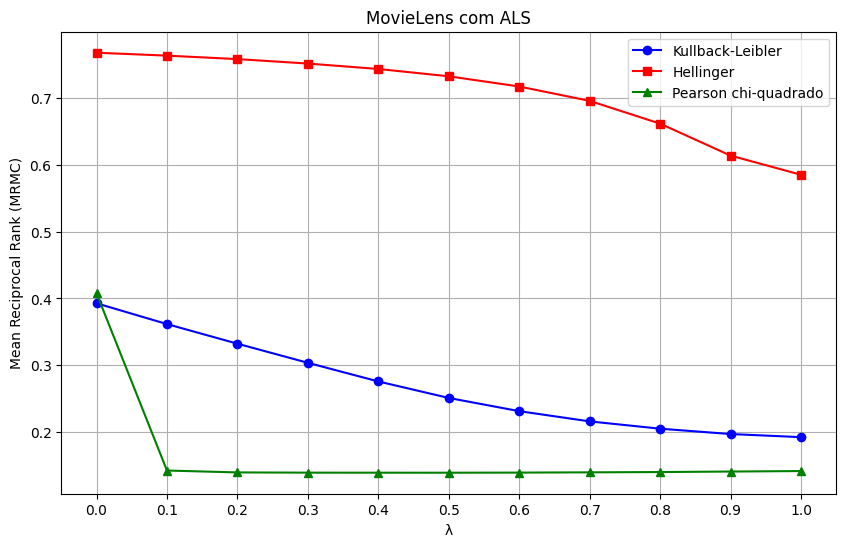

In [8]:
tradeoff_weights = results['Lambda'].drop_duplicates().to_list()
mrmc_kl = results[(results['FairnessMeasure'] == 'kullback-leibler') & (results['Statistic'] == 'mean')]['MRMC'].drop_duplicates().to_list()
mrmc_he = results[(results['FairnessMeasure'] == 'hellinger') & (results['Statistic'] == 'mean')]['MRMC'].drop_duplicates().to_list()
mrmc_pe = results[(results['FairnessMeasure'] == 'pearson') & (results['Statistic'] == 'mean')]['MRMC'].drop_duplicates().to_list()

# Plotando o gráfico
plt.figure(figsize=(10, 6))
plt.plot(tradeoff_weights, mrmc_kl, marker='o', linestyle='-', color='b', label='Kullback-Leibler')
plt.plot(tradeoff_weights, mrmc_he, marker='s', linestyle='-', color='r', label='Hellinger')
plt.plot(tradeoff_weights, mrmc_pe, marker='^', linestyle='-', color='g', label='Pearson chi-quadrado')

plt.xlabel('λ')
plt.xticks(np.arange(0.0, 1.1, 0.1))
plt.ylabel('Mean rank miscalibration (MRMC)')
plt.title('MovieLens com ALS')
plt.legend()
plt.grid(True)
plt.show()


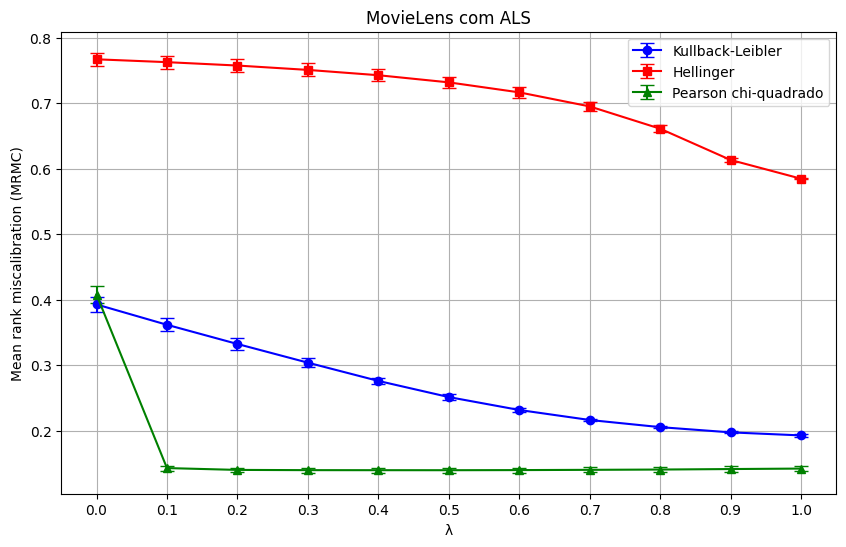

In [9]:
tradeoff_weights = results['Lambda'].drop_duplicates().to_list()
mrmc_kl = results[(results['FairnessMeasure'] == 'kullback-leibler') & (results['Statistic'] == 'mean')]['MRMC'].drop_duplicates().to_list()
mrmc_he = results[(results['FairnessMeasure'] == 'hellinger') & (results['Statistic'] == 'mean')]['MRMC'].drop_duplicates().to_list()
mrmc_pe = results[(results['FairnessMeasure'] == 'pearson') & (results['Statistic'] == 'mean')]['MRMC'].drop_duplicates().to_list()

mrmc_kl_err = results[(results['FairnessMeasure'] == 'kullback-leibler') & (results['Statistic'] == 'stdev')]['MRMC'].drop_duplicates().to_list()
mrmc_he_err = results[(results['FairnessMeasure'] == 'hellinger') & (results['Statistic'] == 'stdev')]['MRMC'].drop_duplicates().to_list()
mrmc_pe_err = results[(results['FairnessMeasure'] == 'pearson') & (results['Statistic'] == 'stdev')]['MRMC'].drop_duplicates().to_list()

# Plotando o gráfico com barras de erro
plt.figure(figsize=(10, 6))
plt.errorbar(tradeoff_weights, mrmc_kl, yerr=mrmc_kl_err, marker='o', linestyle='-', color='b', label='Kullback-Leibler', capsize=5)      
plt.errorbar(tradeoff_weights, mrmc_he, yerr=mrmc_he_err, marker='s', linestyle='-', color='r', label='Hellinger', capsize=5)  
plt.errorbar(tradeoff_weights, mrmc_pe, yerr=mrmc_pe_err, marker='^', linestyle='-', color='g', label='Pearson chi-quadrado', capsize=5)

# Configurando os rótulos e título
plt.xlabel('λ')
plt.ylabel('Mean rank miscalibration (MRMC)')
plt.title('MovieLens com ALS')

# Definindo os valores do eixo x para incrementar de 0.1 em 0.1
plt.xticks(np.arange(0.0, 1.1, 0.1))

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
predictions_user_map

In [ ]:
distributions = Distributions(train.toPandas(), userColumn, itemColumn, genres_map)

In [ ]:
distributions.show_userProfileDist_userRecDist(predictions_user_map, 305)